# 1. Setup and package install

---



In [ ]:
# Run once in Colab
!pip install prophet xgboost --quiet
!pip install category_encoders --quiet


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 5.5 MB/s eta 0:00:00


# 2. Imports and load CSVs

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Load files
train = pd.read_csv('/content/train.csv', parse_dates=['date'])
test = pd.read_csv('/content/test.csv', parse_dates=['date'])
stores = pd.read_csv('/content/stores.csv')
oil = pd.read_csv('/content/oil.csv', parse_dates=['date'])
holidays = pd.read_csv('/content/holidays_events.csv', parse_dates=['date'])
transactions = pd.read_csv('/content/transactions.csv', parse_dates=['date'])
sample_sub = pd.read_csv('/content/sample_submission.csv')

# Quick peek
print(train.shape, test.shape)
train.head()

(3000888, 6) (28512, 5)


,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0
3,3,2013-01-01,1,BEVERAGES,0.0,0
4,4,2013-01-01,1,BOOKS,0.0,0


# 3. Basic EDA checks

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000888 entries, 0 to 3000887
Data columns (total 6 columns):
 #   Column       Dtype         
---  ------       -----         
 0   id           int64         
 1   date         datetime64[ns]
 2   store_nbr    int64         
 3   family       object        
 4   sales        float64       
 5   onpromotion  int64         
dtypes: datetime64[ns](1), float64(1), int64(3), object(1)
memory usage: 137.4+ MB
None
id             0
date           0
store_nbr      0
family         0
sales          0
onpromotion    0
dtype: int64
Train date range: 2013-01-01 00:00:00 2017-08-15 00:00:00
Unique stores: 54 Unique families: 33


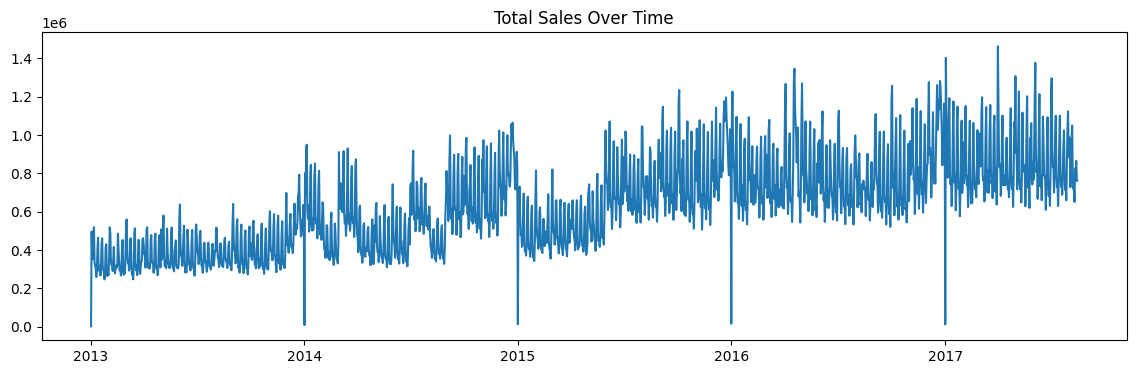

In [2]:
# Info and missing values
print(train.info())
print(train.isnull().sum())

# Date range and unique counts
print("Train date range:", train['date'].min(), train['date'].max())
print("Unique stores:", train['store_nbr'].nunique(), "Unique families:", train['family'].nunique())

# Aggregate total sales over time
daily_sales = train.groupby('date')['sales'].sum().reset_index()
plt.figure(figsize=(14,4))
plt.plot(daily_sales['date'], daily_sales['sales'])
plt.title('Total Sales Over Time')
plt.show()

# 4. Merge supplementary data (create master dataframe for feature engineering)

In [3]:
# Merge store metadata
df = train.merge(stores, on='store_nbr', how='left')

# Merge oil (on date)
df = df.merge(oil[['date', 'dcoilwtico']], on='date', how='left')

# Merge transactions (on date and store)
df = df.merge(transactions, on=['date', 'store_nbr'], how='left')

# Prepare holidays: create binary holiday flag and type
hol = holidays[['date', 'type', 'locale', 'locale_name', 'description', 'transferred']].copy()
hol['is_holiday'] = 1
df = df.merge(hol[['date', 'is_holiday']], on='date', how='left')
df['is_holiday'] = df ['is_holiday'].fillna(0)

# Fill remaining missing numeric values
df['dcoilwtico'] = df['dcoilwtico'].fillna(method='ffill')
df['transactions'] = df['transactions'].fillna(0)

df.head()

/tmp/ipykernel_277/970389215.py:17: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['dcoilwtico'] = df['dcoilwtico'].fillna(method='ffill')


,id,date,store_nbr,family,sales,onpromotion,city,state,type,cluster,dcoilwtico,transactions,is_holiday
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0,Quito,Pichincha,D,13,NaN,0.0,1.0
1,1,2013-01-01,1,BABY CARE,0.0,0,Quito,Pichincha,D,13,NaN,0.0,1.0
2,2,2013-01-01,1,BEAUTY,0.0,0,Quito,Pichincha,D,13,NaN,0.0,1.0
3,3,2013-01-01,1,BEVERAGES,0.0,0,Quito,Pichincha,D,13,NaN,0.0,1.0
4,4,2013-01-01,1,BOOKS,0.0,0,Quito,Pichincha,D,13,NaN,0.0,1.0


# 5. Quick checks for anomalies and missing sales

Negative sales count: 0
NaN sales count: 0


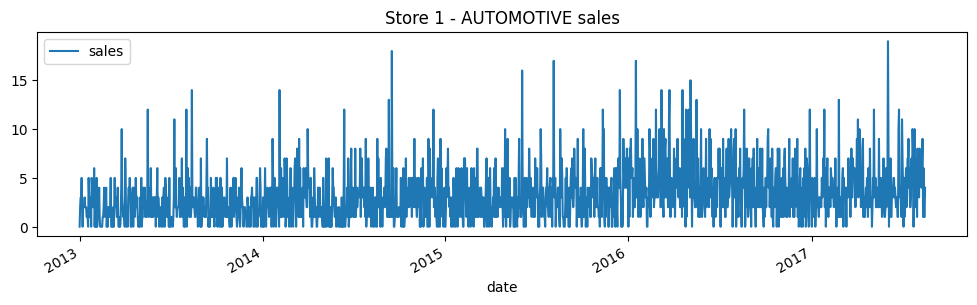

In [4]:
# Check for negative or NaN sales
print("Negative sales count:", (df['sales'] < 0).sum())
print("NaN sales count:", df['sales'].isnull().sum())

# Example: inspect a store-family time series
sample = df[(df['store_nbr']==1) & (df['family']=='AUTOMOTIVE')].sort_values('date')
sample[['date','sales']].set_index('date').plot(figsize=(12,3), title='Store 1 - AUTOMOTIVE sales')
plt.show()


# 6. Feature engineering (lags, rolling, date parts, promo/holiday flags)

In [5]:
# Work on aggregated level for speed example: store_nbr + family group
df = df.sort_values(['store_nbr','family','date'])
group_cols = ['store_nbr','family']

# Create date features
df['day'] = df['date'].dt.day
df['weekday'] = df['date'].dt.weekday
df['month'] = df['date'].dt.month
df['year'] = df['date'].dt.year
df['is_weekend'] = df['weekday'].isin([5,6]).astype(int)

# Lag features and rolling means (grouped)
for lag in [1,7,14,28]:
    df[f'lag_{lag}'] = df.groupby(group_cols)['sales'].shift(lag)

for window in [7,14,28]:
    df[f'roll_mean_{window}'] = (
        df.groupby(group_cols)['sales']
        .shift(1)
        .rolling(window)
        .mean()
    )

# Promotion flag already present as onpromotion in train
df['onpromotion'] = df['onpromotion'].fillna(0)

# Fill NaNs created by shifts with -1 (or use other strategy)
df.fillna(-1, inplace=True)

# Keep a smaller sample for modeling speed (optional)
df_sample = df.sample(frac=0.2, random_state=42)  # remove or adjust for final model


# 7. Train/validation split (time-based)

In [6]:
# Use last 15 days as validation (example)
max_date = df['date'].max()
val_start = max_date - pd.Timedelta(days=30)

train_df = df.loc[df['date'] < val_start].copy()
val_df = df.loc[df['date'] >= val_start].copy()

print(train_df.shape, val_df.shape)


(2999106, 25) (55242, 25)


# 8. Evaluation metrics

In [7]:
from sklearn.metrics import mean_squared_error

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

# 9. XGBoost (tabular model using engineered features)

In [8]:
import xgboost as xgb
from sklearn.preprocessing import LabelEncoder

# Encode categorical column 'family'
le_family = LabelEncoder()
df['family_enc'] = le_family.fit_transform(df['family'].astype(str))

# Rebuild train/validation sets
train_x = train_df.copy()
val_x = val_df.copy()

# Apply same encoding to train and validation
train_x['family_enc'] = le_family.transform(train_x['family'].astype(str))
val_x['family_enc'] = le_family.transform(val_x['family'].astype(str))

# Feature list (store_nbr already numeric, so no encoding needed)
feats = [
    'store_nbr','family_enc','onpromotion','dcoilwtico','transactions',
    'day','weekday','month','year','is_weekend',
    'lag_1','lag_7','lag_14','lag_28',
    'roll_mean_7','roll_mean_14','roll_mean_28'
]

# Convert to XGBoost DMatrix
dtrain = xgb.DMatrix(train_x[feats], label=train_x['sales'])
dval = xgb.DMatrix(val_x[feats], label=val_x['sales'])

# Model parameters
params = {
    'objective': 'reg:squarederror',
    'eval_metric': 'rmse',
    'eta': 0.1,
    'max_depth': 8,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'seed': 42
}

# Train model
watchlist = [(dtrain, 'train'), (dval, 'eval')]
bst = xgb.train(
    params,
    dtrain,
    num_boost_round=200,
    evals=watchlist,
    early_stopping_rounds=20,
    verbose_eval=20
)

# Predict on validation
val_pred = bst.predict(dval)

# Evaluate model
print("Validation RMSE:", rmse(val_x['sales'], val_pred))
print("Validation MAPE:", mape(val_x['sales'], val_pred))

[0]	train-rmse:1001.69868	eval-rmse:1159.93784
[20]	train-rmse:266.90287	eval-rmse:247.88610
[40]	train-rmse:208.94287	eval-rmse:207.52621
[60]	train-rmse:192.50811	eval-rmse:204.52627
[80]	train-rmse:181.22993	eval-rmse:202.13808
[100]	train-rmse:172.21232	eval-rmse:198.71279
[120]	train-rmse:164.31965	eval-rmse:197.37126
[140]	train-rmse:158.56496	eval-rmse:195.87079
[160]	train-rmse:154.32523	eval-rmse:195.23330
[180]	train-rmse:149.81564	eval-rmse:193.68508
[199]	train-rmse:146.37932	eval-rmse:192.88351
Validation RMSE: 192.88350904235878
Validation MAPE: 44.703413218962304


# 10. Preparing Test Predictions & Submission (example using XGBoost)

In [9]:
# Start with combining train and test for the base structure
# Ensure 'sales' column is present for both (NaN for test, actual for train)
full = pd.concat([
    train.assign(is_test=0), # Mark train data
    test.assign(sales=np.nan, is_test=1) # Mark test data, set sales to NaN
], ignore_index=True)

# Sort values to ensure correct lag/rolling calculations
full = full.sort_values(['store_nbr','family','date']).reset_index(drop=True)

# Merge supplementary data as done for 'df'
full = full.merge(stores, on='store_nbr', how='left')
full = full.merge(oil[['date', 'dcoilwtico']], on='date', how='left')
full = full.merge(transactions, on=['date', 'store_nbr'], how='left')

# Prepare holidays and merge
hol_processed = holidays[['date', 'type', 'locale', 'locale_name', 'description', 'transferred']].copy()
hol_processed['is_holiday'] = 1
full = full.merge(hol_processed[['date', 'is_holiday']], on='date', how='left')
full['is_holiday'] = full['is_holiday'].fillna(0)

# Fill missing dcoilwtico and transactions after merges
# Note: 'ffill' for 'dcoilwtico' might propagate NaN from very beginning,
# but the original notebook also uses it.
full['dcoilwtico'] = full['dcoilwtico'].fillna(method='ffill')
full['transactions'] = full['transactions'].fillna(0)

# Create date features
full['day'] = full['date'].dt.day
full['weekday'] = full['date'].dt.weekday
full['month'] = full['date'].dt.month
full['year'] = full['date'].dt.year
full['is_weekend'] = full['weekday'].isin([5,6]).astype(int)

# Lag features and rolling means (grouped)
group_cols = ['store_nbr','family']
for lag in [1,7,14,28]:
    full[f'lag_{lag}'] = full.groupby(group_cols)['sales'].shift(lag)

for window in [7,14,28]:
    full[f'roll_mean_{window}'] = (
        full.groupby(group_cols)['sales']
        .shift(1) # shift sales by 1 day before calculating rolling mean
        .rolling(window)
        .mean()
    )

# Fill NaNs created by shifts and rolls with -1.
# This should NOT affect the 'sales' column for test data, which we want to remain NaN.
# So, selectively fill.
feature_cols_with_potential_nan = [f'lag_{lag}' for lag in [1,7,14,28]] + \
                                  [f'roll_mean_{window}' for window in [7,14,28]]

for col in feature_cols_with_potential_nan:
    full[col] = full[col].fillna(-1)

# Ensure 'onpromotion' is clean
full['onpromotion'] = full['onpromotion'].fillna(0)

# Encode family
# le_family was fitted on df['family'] which was derived from train.
# It should be safe to use here.
full['family_enc'] = le_family.transform(full['family'].astype(str))


/tmp/ipykernel_277/2052485903.py:25: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  full['dcoilwtico'] = full['dcoilwtico'].fillna(method='ffill')


# 11. Joblib se model save and load krna

In [10]:
import joblib

# Save with joblib (faster for large models)
joblib.dump(bst, "sales_model.joblib")

# Load joblib model
loaded_model = joblib.load("sales_model.joblib")

# Test prediction
# Pick one sample row from validation dataframe with correct columns
sample_input = val_x[feats].iloc[[0]]   # feats = list of feature columns

# Convert to DMatrix with feature names intact
dtest = xgb.DMatrix(sample_input, feature_names=feats)

# Predict
print("Prediction:", loaded_model.predict(dtest))


Prediction: [-1.9237236]


In [11]:
dval = xgb.DMatrix(val_x[feats], label=val_x['sales'])
val_pred = loaded_model.predict(dval)
print("dval",val_pred)
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

rmse = np.sqrt(mean_squared_error(val_x['sales'], val_pred))
y_true = val_x['sales'].values
y_pred = val_pred

mask = y_true != 0
mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

print("Validation MAPE:", mape)

print("Validation RMSE:", rmse)
print("Validation MAPE:", mape)



dval [-1.9237236   6.011555    6.2403674  ...  0.01184057 -0.8893668
 -0.36118156]
Validation MAPE: 44.703413218962304
Validation RMSE: 192.88350904235878
Validation MAPE: 44.703413218962304
